## Data Cleaning !!!

In [79]:
from datasets import load_dataset

ds = load_dataset("roneneldan/TinyStories")

In [80]:
ds.keys()

dict_keys(['train', 'validation'])

In [81]:
train_data = ds['train']
validate_data = ds['validation']
train_data = train_data.to_pandas()
validate_data = validate_data.to_pandas()

In [82]:
train_data.shape , validate_data.shape

((2119719, 1), (21990, 1))

In [83]:
train_data.head()

,text
0,"One day, a little girl named Lily found a need..."
1,"Once upon a time, there was a little car named..."
2,"One day, a little fish named Fin was swimming ..."
3,"Once upon a time, in a land full of trees, the..."
4,"Once upon a time, there was a little girl name..."


In [84]:
train_data = train_data[train_data['text'].str.len() > 0].reset_index(drop=True)
validate_data = validate_data[validate_data['text'].str.len() > 0].reset_index(drop=True)

In [85]:
train_data = train_data.reset_index(drop=True)
validate_data = validate_data.reset_index(drop=True)

In [86]:
len(train_data) , len(validate_data)

(2119489, 21990)

In [87]:
import os
from google.colab import drive
drive.mount('/content/drive')


folder_path = "/content/drive/MyDrive/Kaya"
os.makedirs(folder_path, exist_ok=True)
print("Folder created:", folder_path)


base_dir = "/content/drive/MyDrive/Kaya"
folders = [
    "datasets",
    "tokenizers",
    "checkpoints",
    "logs"
]
for folder in folders:
    os.makedirs(os.path.join(base_dir, folder), exist_ok=True)

print("Project folders created successfully!")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folder created: /content/drive/MyDrive/Kaya
Project folders created successfully!


## BPE Tokenizer
using minBPE repo to tokenize the sequence of length.

In [88]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace
from typing import Optional, Tuple

tokenizer_path = '/content/drive/MyDrive/Kaya/tokenizers/my_tokenizer.json'
if  os.path.exists(tokenizer_path):
  print("Tokenizer already built...Loading......")
  tokenizer = Tokenizer.from_file(tokenizer_path)
  print("tokenizer loaded ")

else:
  print("Traning New Tokeinizer :) :( ")
  tokenizer = Tokenizer(BPE(unk_token="<unk>"))
  tokenizer.pre_tokenizer = Whitespace()

  trainer = BpeTrainer(
      vocab_size=8000,
      special_tokens=["<pad>", "<unk>", "<bos>", "<eos>"]
  )

  texts = train_data["text"].dropna().tolist()

  tokenizer.train_from_iterator(
      texts,
      trainer=trainer
  )

  tokenizer.save(tokenizer_path)
  print("Tokenizer Saved ....")

Tokenizer already built...Loading......
tokenizer loaded 


### Coustom DataSet

In [89]:
# Create a coustom dataset class that tokenize when the text when required
# what does it do
# 1. convert the text into tokens(integers)
# 2. add extra shift as per the context_length
# 3. add padding if length of text is shorter than context_length +1
# 4. convert to tensor
# 5. return x and y as shifted by 1
import torch
from torch.utils.data import Dataset

class CustomDataset(Dataset):
  def __init__(self , texts  , tokenizer , max_length , pad_token_id =0):
    self.texts = texts
    self.tokenizer = tokenizer
    self.max_length = max_length
    self.pad_token_id = pad_token_id


  def __len__(self):
    return len(self.texts)


  def __getitem__(self , index):
    # convert into numeric
    ids = self.tokenizer.encode(self.texts[index]).ids

    # need one extra token for the shift
    ids = ids[:self.max_length+1]

    # padding required if shorter than max_lenth+1
    if len(ids) < self.max_length+1:
      ids = ids + [self.pad_token_id]*(self.max_length+1 - len(ids))

    # convert to tensor
    ids = torch.tensor(ids)

    x = ids[:-1]
    y = ids[1:]

    return x ,y


In [90]:
# build the dataset
dataset = CustomDataset(train_data['text'] , tokenizer , max_length=256 ,pad_token_id=0)


### DataLoader

In [91]:
from torch.utils.data import DataLoader
batch_size=32
context_length=256
num_worker=2

train_loader = DataLoader(
    dataset ,
    batch_size=batch_size ,
    shuffle = True,
    pin_memory=True,
    drop_last=True,  # Discard incomplete final batch to maintain shape uniformity
    num_workers=num_worker
)

# now lets iter all the text and convert them into tensors
x_batch, y_batch = next(iter(train_loader))
print(x_batch.shape)
print(y_batch.shape)


torch.Size([32, 256])
torch.Size([32, 256])


data loader

dfjrdyjdyfjk


In [92]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
torch.manual_seed(42)
context_length=256
n_embd = 384
n_head = 6
n_layer = 6
dropout = 0.2
vocab_size = tokenizer.get_vocab_size()

In [93]:
# Single head attention
class SingleHeadAttention(nn.Module):

  def __init__(self, n_embd ,head_dim, context_length , dropout=0.1 , causal=True):
    super().__init__()
    self.head_dim = head_dim
    self.causal = causal

    # three learnable parameters
    self.wk = nn.Linear(n_embd , head_dim , bias=False)
    self.wq = nn.Linear(n_embd , head_dim , bias=False)
    self.wv = nn.Linear(n_embd , head_dim , bias=False)

    # Fixed mask — not a parameter, but needs to travel to GPU with the model
    self.register_buffer('tril' ,
                         torch.tril(torch.ones(context_length, context_length)))

    # dropout randomly zeros some weight to prevent overfitting
    self.dropout = nn.Dropout(dropout)

  def forward(self , x):
    B , T , _ = x.shape

    Q = self.wq(x)
    K = self.wk(x)
    V = self.wv(x)

    # Scale dot-product attention
    scores = Q @ K.transpose(-2,-1) * (self.head_dim)**-0.5

    # Apply causal mask — tokens can't see future positions
    if self.causal:
      scores = scores.masked_fill(self.tril[:T, :T] == 0, float('-inf'))


    # Softmax layer
    weights = F.softmax(scores , dim=-1)  # there are more than one batch and each batch has more than one one word and eah word has q , v , k
    out = weights @ V

    return out




In [94]:
# test the single attention
head = SingleHeadAttention(256, head_dim= 64, context_length=128 ,causal=True)
x = torch.randn(2,10,256)
print(head(x).shape)

torch.Size([2, 10, 64])


In [95]:
# Multi Head Attention
class MultiHeadAttention(nn.Module):
  """ Multiple head of self attention """
  def __init__(self ,embed_dim, num_heads, context_length, dropout=0.1 ,causal=True):
    super().__init__()

    assert embed_dim % num_heads == 0
    head_dim = embed_dim // num_heads
    self.heads = nn.ModuleList([SingleHeadAttention(embed_dim, head_dim, context_length, dropout,causal=True) for _ in range(num_heads)])
    self.proj = nn.Linear(embed_dim, embed_dim)
    self.dropout = nn.Dropout(dropout)

  def forward(self,x):
    out = torch.cat([h(x) for h in self.heads] , dim = -1)
    out = self.dropout(self.proj(out))
    return out



In [96]:
# lets cehck the multihead attention
mha = MultiHeadAttention(embed_dim=256, num_heads=4, context_length=128,causal=True)
x = torch.randn(2, 10 , 256)
print(mha(x).shape)

torch.Size([2, 10, 256])


In [97]:
# Feed forward
class FeedForward(nn.Module):
  def __init__(self , embed_dim , dropout=0.1):
    super().__init__()
    self.net = nn.Sequential(
        nn.Linear(embed_dim , 4 * embed_dim),
        nn.ReLU(),
        nn.Linear(4*embed_dim , embed_dim),
        nn.Dropout(dropout)
    )

  def forward(self , x):
    return self.net(x)

In [98]:
# Block
class Block(nn.Module):
  def __init__(self , embed_dim , num_heads , context_length , dropout = 0.1,causal=True):
    super().__init__()

    self.self_attention = MultiHeadAttention(embed_dim , num_heads , context_length , dropout,causal=True)
    self.feed_forward = FeedForward(embed_dim , dropout)

    self.layer_norm_1 = nn.LayerNorm(embed_dim)
    self.layer_norm_2 = nn.LayerNorm(embed_dim)

  def forward(self , x):
    # Attention with residual connection
    x = x + self.self_attention(self.layer_norm_1(x))
    x = x + self.feed_forward(self.layer_norm_2(x))

    return x



In [99]:
# Embedding + positional encoding
class TransformerEmbedding(nn.Module):
  def __init__(self , vocab_size , embed_dim , context_length , dropout=0.1):
    super().__init__()

    self.token_embedding = nn.Embedding(vocab_size , embed_dim)
    self.pos_embed = nn.Embedding(context_length , embed_dim)

    self.dropout = nn.Dropout(dropout)
    self.context_length = context_length

  def forward(self, idx):
      B, T = idx.shape
      tok = self.token_embedding(idx)
      pos = self.pos_embed(torch.arange(T, device=idx.device))
      return self.dropout(tok + pos)


In [100]:
class Kaya(nn.Module):
    def __init__(self, vocab_size, n_embd, num_heads, num_layers, context_length, dropout=0.1):
        super().__init__()
        self.context_length = context_length

        # 1. Embedding layer
        self.embedding = TransformerEmbedding(vocab_size, n_embd, context_length, dropout)

        # 2. Stack of N Transformer blocks
        self.blocks = nn.Sequential(*[
            Block(n_embd, num_heads, context_length, dropout, causal=True)
            for _ in range(num_layers)
        ])

        # 3. Final LayerNorm before projection
        self.ln_final = nn.LayerNorm(n_embd)

        # 4. Language model head — projects to vocab scores
        self.lm_head = nn.Linear(n_embd, vocab_size, bias=False)

        # Weight tying
        self.lm_head.weight = self.embedding.token_embedding.weight

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx: torch.Tensor, targets: Optional[torch.Tensor] = None) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        x      = self.embedding(idx)   # (B, T, n_embd)
        x      = self.blocks(x)        # (B, T, n_embd)
        x      = self.ln_final(x)      # (B, T, n_embd)
        logits = self.lm_head(x)       # (B, T, vocab_size)

        loss = None
        if targets is not None:
            B, T, C = logits.shape
            loss = F.cross_entropy(logits.view(B * T, C), targets.view(B * T))

        return logits, loss

    @torch.no_grad()
    def generate(self, idx: torch.Tensor, max_new_tokens: int) -> torch.Tensor:
        for _ in range(max_new_tokens):
            idx_cond  = idx[:, -self.context_length:]
            logits, _ = self(idx_cond)
            logits    = logits[:, -1, :]
            probs     = F.softmax(logits, dim=-1)
            idx_next  = torch.multinomial(probs, num_samples=1)
            idx       = torch.cat([idx, idx_next], dim=1)
        return idx

In [101]:
model = Kaya(
    vocab_size     = vocab_size,
    n_embd         = n_embd,
    num_heads      = n_head,
    num_layers     = n_layer,
    context_length = context_length,
    dropout        = dropout
)

In [104]:

model = model
# print the number of parameters in the model
print(sum(p.numel() for p in model.parameters())/1e6, 'M parameters')

13.810944 M parameters


In [103]:
!pip install torchinfo

In [105]:
from torchinfo import summary

summary(
    model,
    input_size=(32, 128),  # (batch_size, seq_length)
    dtypes=[torch.long]
)

Layer (type:depth-idx)                                  Output Shape              Param #
Kaya                                                    [32, 128, 8000]           --
├─TransformerEmbedding: 1-1                             [32, 128, 384]            --
│    └─Embedding: 2-1                                   [32, 128, 384]            3,072,000
│    └─Embedding: 2-2                                   [128, 384]                98,304
│    └─Dropout: 2-3                                     [32, 128, 384]            --
├─Sequential: 1-2                                       [32, 128, 384]            --
│    └─Block: 2-4                                       [32, 128, 384]            --
│    │    └─LayerNorm: 3-1                              [32, 128, 384]            768
│    │    └─MultiHeadAttention: 3-2                     [32, 128, 384]            590,208
│    │    └─LayerNorm: 3-3                              [32, 128, 384]            768
│    │    └─FeedForward: 3-4              

In [106]:
@torch.no_grad()
def evaluate(model, val_loader, num_batches=50):
    model.eval()
    total_loss = 0.0
    count = 0
    for i, (x, y) in enumerate(val_loader):
        if i >= num_batches:
            break
        x, y = x.to(device), y.to(device)
        _, loss = model(x, y)
        total_loss += loss.item()
        count += 1
    model.train()
    return total_loss / count if count > 0 else float('inf')

In [107]:


import json
import os

LOG_PATH = "/content/drive/MyDrive/Kaya/logs/training_log.json"

def load_log():
    """Load existing log from Drive (so resume doesn't overwrite)"""
    if os.path.exists(LOG_PATH):
        with open(LOG_PATH, "r") as f:
            data = json.load(f)
        print(f" Loaded existing log — {len(data['train'])} train, {len(data['val'])} val entries")
        return data
    return {"train": [], "val": []}

def save_log(log):
    """Save log to Drive"""
    os.makedirs(os.path.dirname(LOG_PATH), exist_ok=True)
    with open(LOG_PATH, "w") as f:
        json.dump(log, f, indent=2)

def log_train(log, step, epoch, loss, avg, lr):
    log["train"].append({
        "step"  : step,
        "epoch" : epoch,
        "loss"  : round(loss, 4),
        "avg"   : round(avg,  4),
        "lr"    : lr
    })
    save_log(log)

def log_val(log, step, epoch, val_loss, ppl, lr):
    log["val"].append({
        "step"     : step,
        "epoch"    : epoch,
        "val_loss" : round(val_loss, 4),
        "ppl"      : round(ppl,      2),
        "lr"       : lr
    })
    save_log(log)

# Load at start (safe for resume)
training_log = load_log()

 Loaded existing log — 23 train, 8 val entries


In [74]:
# ═════════════════════════════════════════════════════════════
# STEP 1 — DATALOADER (updated for 3-day T4 training)
# 10% data, context=128 → ~2.5 hrs/epoch → 2 epochs per session
# ═════════════════════════════════════════════════════════════
batch_size  = 32
num_workers = 2


import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0) if device == 'cuda' else 'None'}")

# Also move model to device — restart loses this too
model = model.to(device)
print(f"Model on: {next(model.parameters()).device}")
# Use 10% of training data
# Full 2.1M stories → 1 epoch takes ~20hrs on T4 (too slow)
# 10% = 211k stories → 1 epoch takes ~2.5hrs on T4 (perfect)
subset_size  = int(len(train_data) * 0.10)
train_subset = train_data['text'].tolist()[:subset_size]
val_subset   = validate_data['text'].tolist()[:3000]   # 3k val stories is enough

train_dataset = CustomDataset(train_subset, tokenizer, context_length)
val_dataset   = CustomDataset(val_subset,   tokenizer, context_length)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          pin_memory=True, drop_last=True, num_workers=num_workers)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False,
                          pin_memory=True, drop_last=True, num_workers=num_workers)

print(f"Train stories : {subset_size:,}")
print(f"Train batches : {len(train_loader):,}")     # ~6,600 batches
print(f"Val stories   : {len(val_subset):,}")
print(f"Val batches   : {len(val_loader):,}")


# ═════════════════════════════════════════════════════════════
# STEP 2 — OPTIMIZER + SCHEDULER
# ═════════════════════════════════════════════════════════════

# AdamW — standard for transformers
# weight_decay=0.01 → small penalty on large weights (prevents overfitting)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.01)

# ReduceLROnPlateau — cuts LR in half when val loss stops improving
# patience=1 → waits 1 eval before reducing
# This helps in later epochs when loss plateaus
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=1
)


# ═══════════════════════════════════════════════════════════════
# STEP 3 — CHECKPOINT UTILS (fixed)
# ═══════════════════════════════════════════════════════════════

def save_checkpoint(model, optimizer, scheduler, epoch, step, batch_idx, train_loss, val_loss):
    path = os.path.join("/content/drive/MyDrive/Kaya/checkpoints", f"kaya_epoch{epoch}_step{step}.pt")
    torch.save({
        "epoch"      : epoch,
        "step"       : step,
        "batch_idx"  : batch_idx,   # ← NEW: which batch inside this epoch
        "model"      : model.state_dict(),
        "optimizer"  : optimizer.state_dict(),
        "scheduler"  : scheduler.state_dict(),
        "train_loss" : train_loss,
        "val_loss"   : val_loss,
    }, path)
    print(f"   Saved → {path}")


def load_checkpoint(model, optimizer, scheduler, path):
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["model"])
    optimizer.load_state_dict(ckpt["optimizer"])
    scheduler.load_state_dict(ckpt["scheduler"])
    batch_idx = ckpt.get("batch_idx", 0)   # backward compat with old checkpoints
    print(f"   Resumed → epoch {ckpt['epoch']} | step {ckpt['step']} | batch {batch_idx}")
    print(f"     train={ckpt['train_loss']:.4f} | val={ckpt['val_loss']:.4f}")
    return ckpt["epoch"], ckpt["step"], batch_idx


# ═══════════════════════════════════════════════════════════════
# STEP 5 — RESUME SETTINGS (fixed)
# ═══════════════════════════════════════════════════════════════

RESUME      = True
RESUME_PATH = "/content/drive/MyDrive/Kaya/checkpoints/kaya_epoch3_step14000.pt"

start_epoch  = 3
global_step  = 0
resume_batch = 4000  # ← NEW

if RESUME and RESUME_PATH:
    start_epoch, global_step, resume_batch = load_checkpoint(
        model, optimizer, scheduler, RESUME_PATH
    )


# ═══════════════════════════════════════════════════════════════
# STEP 6 — TRAINING LOOP (fixed)
# ═══════════════════════════════════════════════════════════════

epochs_this_session = 2
eval_every          = 300
save_every          = 500

model.train()

# ═══════════════════════════════════════════════════════════════
# TRAINING LOOP — updated with logger
# ═══════════════════════════════════════════════════════════════

for epoch in range(start_epoch, start_epoch + epochs_this_session):
    print(f"\n{'='*55}")
    print(f"EPOCH {epoch+1} | LR: {optimizer.param_groups[0]['lr']:.2e}")
    print(f"{'='*55}")

    epoch_loss    = 0
    skipped_steps = 0
    skip_until    = resume_batch if epoch == start_epoch else 0

    if skip_until > 0:
        print(f"  Skipping {skip_until} batches to resume point...")

    for step, (x, y) in enumerate(train_loader):

        if step < skip_until:
            skipped_steps += 1
            continue

        x, y = x.to(device), y.to(device)

        logits, loss = model(x, y)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        epoch_loss  += loss.item()
        global_step += 1

        actual_steps = step - skipped_steps + 1

        if global_step % 100 == 0:
            avg = epoch_loss / actual_steps
            lr  = optimizer.param_groups[0]['lr']
            print(f"  Ep {epoch+1} | Step {global_step} | "
                  f"Loss {loss.item():.4f} | Avg {avg:.4f} | LR {lr:.2e}")

            # ← NEW: log train
            log_train(training_log, global_step, epoch+1, loss.item(), avg, lr)

        if global_step % eval_every == 0:
            val_loss = evaluate(model, val_loader)
            scheduler.step(val_loss)
            ppl = math.exp(val_loss)
            lr  = optimizer.param_groups[0]['lr']
            print(f"\n   Val Loss : {val_loss:.4f} | PPL : {ppl:.2f} | "
                  f"LR : {lr:.2e}\n")

            # ← NEW: log val
            log_val(training_log, global_step, epoch+1, val_loss, ppl, lr)

        if global_step % save_every == 0:
            val_loss = evaluate(model, val_loader)
            save_checkpoint(model, optimizer, scheduler,
                            epoch+1, global_step, step,
                            loss.item(), val_loss)

    resume_batch = 0

    val_loss = evaluate(model, val_loader)
    ppl      = math.exp(val_loss)
    save_checkpoint(model, optimizer, scheduler,
                    epoch+1, global_step, 0,
                    epoch_loss / max(actual_steps, 1), val_loss)
    log_val(training_log, global_step, epoch+1, val_loss, ppl,
            optimizer.param_groups[0]['lr'])
    print(f"\n  Epoch {epoch+1} done | "
          f"Avg Loss : {epoch_loss/max(actual_steps,1):.4f} | "
          f"Val Loss : {val_loss:.4f}")

Device: cuda
GPU: Tesla T4
Model on: cuda:0
Train stories : 211,948
Train batches : 6,623
Val stories   : 3,000
Val batches   : 93
  ✅ Resumed → epoch 3 | step 14000 | batch 999
     train=1.4346 | val=1.2589

EPOCH 4 | LR: 1.50e-04
  ⏩ Skipping 999 batches to resume point...
  Ep 4 | Step 14100 | Loss 1.3331 | Avg 1.3801 | LR 1.50e-04

  📊 Val Loss : 1.2574 | PPL : 3.52 | LR : 7.50e-05

  Ep 4 | Step 14200 | Loss 1.2807 | Avg 1.3682 | LR 7.50e-05
  Ep 4 | Step 14300 | Loss 1.3050 | Avg 1.3617 | LR 7.50e-05
  Ep 4 | Step 14400 | Loss 1.2518 | Avg 1.3620 | LR 7.50e-05

  📊 Val Loss : 1.2457 | PPL : 3.48 | LR : 7.50e-05

  Ep 4 | Step 14500 | Loss 1.3775 | Avg 1.3586 | LR 7.50e-05
  ✅ Saved → /content/drive/MyDrive/Kaya/checkpoints/kaya_epoch4_step14500.pt


KeyboardInterrupt: 

Train points : 23
Val points   : 8


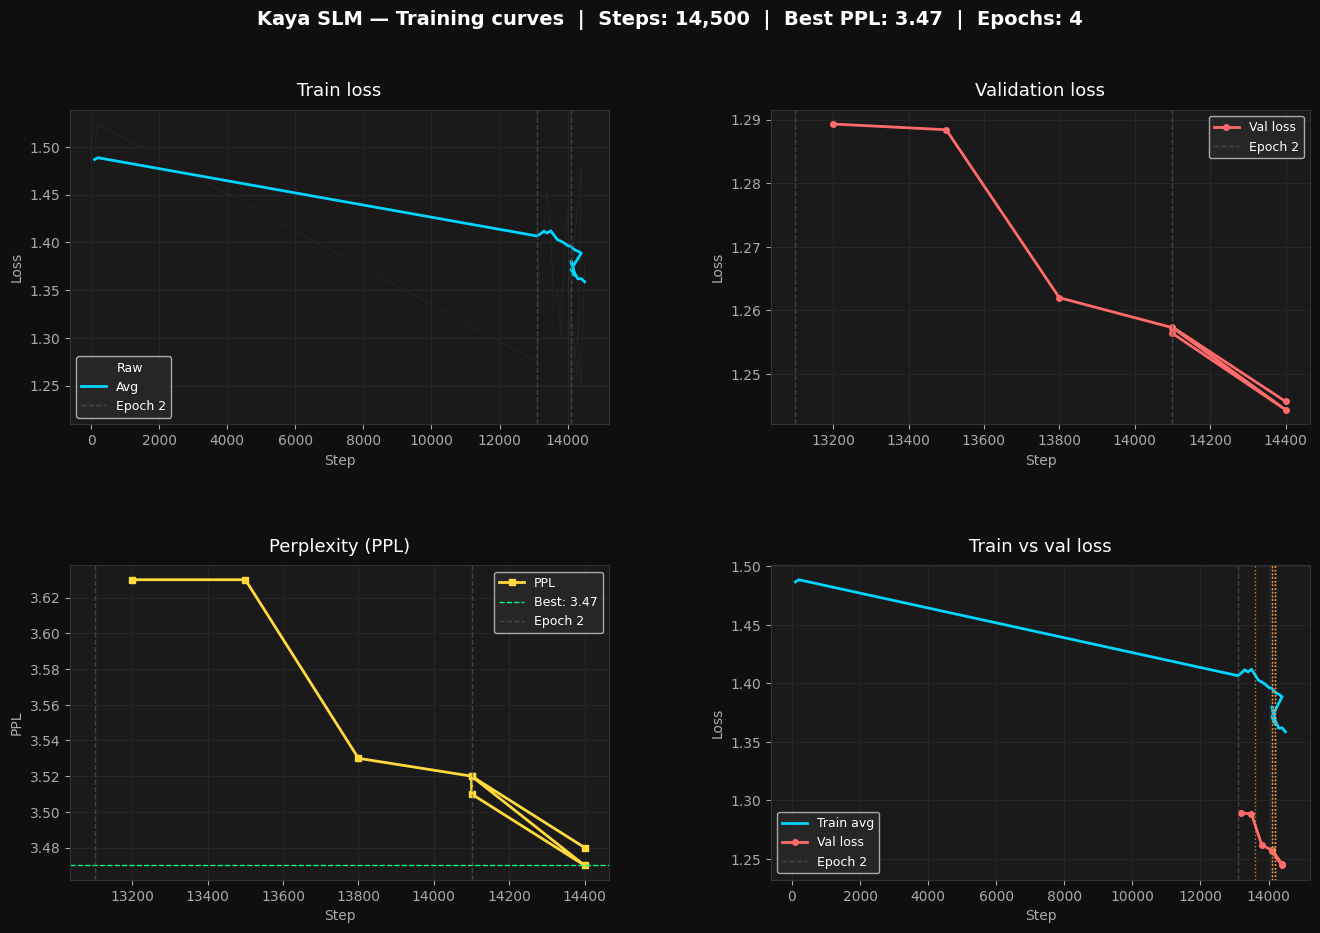

Saved to Drive 


In [108]:
# ═══════════════════════════════════════════════════════════════
# KAYA — PLOT FROM DRIVE LOG
# ═══════════════════════════════════════════════════════════════

import json
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Load from Drive
with open("/content/drive/MyDrive/Kaya/logs/training_log.json", "r") as f:
    log = json.load(f)

train_log = log["train"]
val_log   = log["val"]

print(f"Train points : {len(train_log)}")
print(f"Val points   : {len(val_log)}")

# Extract
steps_train = [x["step"]     for x in train_log]
loss_raw    = [x["loss"]     for x in train_log]
loss_avg    = [x["avg"]      for x in train_log]
steps_val   = [x["step"]     for x in val_log]
val_loss    = [x["val_loss"] for x in val_log]
ppl_vals    = [x["ppl"]      for x in val_log]
epochs      = [x["epoch"]    for x in val_log]

# Find epoch boundary steps for vertical lines
epoch_boundaries = []
seen = set()
for x in train_log:
    if x["epoch"] not in seen:
        seen.add(x["epoch"])
        if x["epoch"] > 1:
            epoch_boundaries.append(x["step"])
fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor('#0f0f0f')
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.3)

def style_ax(ax, title, xlabel, ylabel):
    ax.set_facecolor('#1a1a1a')
    ax.set_title(title, color='white', fontsize=13, pad=10)
    ax.set_xlabel(xlabel, color='#aaa', fontsize=10)
    ax.set_ylabel(ylabel, color='#aaa', fontsize=10)
    ax.tick_params(colors='#aaa')
    ax.grid(True, color='#2a2a2a', linewidth=0.5)
    for spine in ax.spines.values():
        spine.set_edgecolor('#333')

def add_epoch_lines(ax):
    for i, s in enumerate(epoch_boundaries):
        ax.axvline(x=s, color='#555', linewidth=1.0,
                   linestyle='--', alpha=0.7,
                   label=f'Epoch {i+2}' if i == 0 else '')

ax1 = fig.add_subplot(gs[0, 0])
style_ax(ax1, 'Train loss', 'Step', 'Loss')
ax1.plot(steps_train, loss_raw, color='#333', linewidth=0.7, alpha=0.4, label='Raw')
ax1.plot(steps_train, loss_avg, color='#00d4ff', linewidth=2.0, label='Avg')
add_epoch_lines(ax1)
ax1.legend(facecolor='#2a2a2a', labelcolor='white', fontsize=9)

ax2 = fig.add_subplot(gs[0, 1])
style_ax(ax2, 'Validation loss', 'Step', 'Loss')
ax2.plot(steps_val, val_loss, color='#ff6b6b', linewidth=2.0,
         marker='o', markersize=4, label='Val loss')
add_epoch_lines(ax2)
ax2.legend(facecolor='#2a2a2a', labelcolor='white', fontsize=9)


ax3 = fig.add_subplot(gs[1, 0])
style_ax(ax3, 'Perplexity (PPL)', 'Step', 'PPL')
ax3.plot(steps_val, ppl_vals, color='#ffd93d', linewidth=2.0,
         marker='s', markersize=4, label='PPL')
ax3.axhline(y=min(ppl_vals), color='#00ff88', linewidth=1.0,
            linestyle='--', label=f'Best: {min(ppl_vals):.2f}')
add_epoch_lines(ax3)
ax3.legend(facecolor='#2a2a2a', labelcolor='white', fontsize=9)


ax4 = fig.add_subplot(gs[1, 1])
style_ax(ax4, 'Train vs val loss', 'Step', 'Loss')
ax4.plot(steps_train, loss_avg, color='#00d4ff', linewidth=2.0, label='Train avg')
ax4.plot(steps_val,   val_loss, color='#ff6b6b', linewidth=2.0,
         marker='o', markersize=4, label='Val loss')
add_epoch_lines(ax4)
ax4.legend(facecolor='#2a2a2a', labelcolor='white', fontsize=9)


lr_changes = []
prev_lr = None
for x in train_log:
    if x["lr"] != prev_lr and prev_lr is not None:
        lr_changes.append((x["step"], x["lr"]))
    prev_lr = x["lr"]

for step, lr in lr_changes:
    ax4.axvline(x=step, color='#ff9f43', linewidth=1.0,
                linestyle=':', alpha=0.8, label=f'LR→{lr:.1e}')


fig.suptitle(
    f'Kaya SLM — Training curves  |  '
    f'Steps: {max(steps_train):,}  |  '
    f'Best PPL: {min(ppl_vals):.2f}  |  '
    f'Epochs: {max(epochs)}',
    color='white', fontsize=14, fontweight='bold', y=0.98
)

plt.savefig('/content/drive/MyDrive/Kaya/logs/training_curves.png',
            dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print(f"Saved to Drive ")

In [111]:
import torch

checkpoint_path = "/content/drive/MyDrive/Kaya/checkpoints/kaya_epoch4_step14500.pt"

# Load the file
checkpoint = torch.load(checkpoint_path, map_location=device)

# 1. Print the keys to see what's inside
# If it's a state_dict, you'll see layer names like 'transformer.h.0.attn.weight'
print("Checkpoint keys found:", checkpoint.keys())

# 2. Check the size of the first weight
# Pick a known layer name from your model
first_key = list(checkpoint.keys())[0]
print(f"Shape of first saved weight: {checkpoint[first_key].shape}")

Checkpoint keys found: dict_keys(['epoch', 'step', 'batch_idx', 'model', 'optimizer', 'scheduler', 'train_loss', 'val_loss'])


AttributeError: 'int' object has no attribute 'shape'

In [112]:
# Load the full checkpoint dictionary
checkpoint = torch.load("/content/drive/MyDrive/Kaya/checkpoints/kaya_epoch4_step14500.pt", map_location=device)

# EXTRACT only the 'model' portion
model_weights = checkpoint['model']

# Now load only the weights into your Kaya() instance
model.load_state_dict(model_weights)
model.to(device)
model.eval() # IMPORTANT: Always set to eval mode for inference

Kaya(
  (embedding): TransformerEmbedding(
    (token_embedding): Embedding(8000, 384)
    (pos_embed): Embedding(256, 384)
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (blocks): Sequential(
    (0): Block(
      (self_attention): MultiHeadAttention(
        (heads): ModuleList(
          (0-5): 6 x SingleHeadAttention(
            (wk): Linear(in_features=384, out_features=64, bias=False)
            (wq): Linear(in_features=384, out_features=64, bias=False)
            (wv): Linear(in_features=384, out_features=64, bias=False)
            (dropout): Dropout(p=0.2, inplace=False)
          )
        )
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
      )
      (feed_forward): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=384, out_features=1536, bias=True)
          (1): ReLU()
          (2): Linear(in_features=1536, out_features=384, bias=True)
          (3): Dropout(p=0.2, inplac

In [113]:
# Check if the model is now loaded with actual weights
# This should print the shapes of the actual layers (e.g., torch.Size([768, 768]))
for name, param in model.named_parameters():
    print(f"Layer: {name} | Shape: {param.shape}")
    break # Just print the first one to verify

Layer: embedding.token_embedding.weight | Shape: torch.Size([8000, 384])


In [114]:
# 1. Ensure the tokenizer is initialized correctly (Vocab size must match the model's 8000)
# If you trained with a custom vocab, ensure you load that exact tokenizer.json
assert tokenizer.get_vocab_size() == 8000, f"Mismatch! Model has 8000, Tokenizer has {tokenizer.get_vocab_size()}"

# 2. Run the generator with the proper model
model.eval()

# Let's try a very simple, single-sentence generation to verify coherence
prompt = "A brave little owl lived in a"
ids = tokenizer.encode(prompt).ids
idx = torch.tensor([ids], device=device)

with torch.no_grad():
    # Generate 10 tokens
    for _ in range(10):
        logits, _ = model(idx[:, -256:])
        # Use greedy search (argmax) for the sanity check
        next_id = torch.argmax(logits[:, -1, :], dim=-1)
        idx = torch.cat([idx, next_id.unsqueeze(0)], dim=1)

print("Sanity Check Output:", tokenizer.decode(idx[0].tolist()))

Sanity Check Output: A brave little owl lived in a big tree . He was very brave and he loved


In [119]:
# Run this to get your 5 stories
test_cases = [
    ("A brave little owl", "a misty forest", "courage grows when you try"),
    ("A curious forest sprite", "a glowing underwater cave", "being different is a superpower"),
    ("A clumsy baby bear", "a city of clouds", "patience leads to great things"),
    ("A wise old turtle", "a desert of purple sand", "listening is a form of love"),
    ("A fast cheetah cub", "a field of ticking clocks", "hard work brings the sweetest rewards")
]

for char, setting, moral in test_cases:
    print(f"\n--- Testing Story: {char} ---")
    print(generate_story(char, setting, moral))


--- Testing Story: A brave little owl ---
In stru ction : W r ite a short children ' s story . C ha rac ter : A brave little owl . S et ting : a mis ty forest . Moral : courage grows when you try . S tory : Owl , to see the big trees and animals . Th ang les : " We should be kind of animals !" But B ta ce was too young for him in trouble ! He kept on dancing around with his whispers . The next day , An evil storm came . It blew H ge away from his village spe ctive and he started barking again . This time it passed by an old man who had been watching them . The old man said : " Don ' t worry , I will take care of you ." Without hesit ation , M ind ic al vis continued to dance around the town .

--- Testing Story: A curious forest sprite ---
In stru ction : W r ite a short children ' s story . C ha rac ter : A curious forest spr ite . S et ting : a glowing under water cave . Moral : being different is a super power . S tory : Everyone looks after it and always appear in the dark dep ths

In [118]:
@torch.no_grad()
def generate_forced_story(char, setting, moral, min_tokens=100, max_tokens=250):
    model.eval()
    prompt = f"Instruction: Write a short children's story. Character: {char}. Setting: {setting}. Moral: {moral}.\nStory: {char} "

    ids = tokenizer.encode(prompt).ids
    idx = torch.tensor([ids], dtype=torch.long, device=device)

    for _ in range(max_tokens):
        logits, _ = model(idx[:, -256:])
        logits = logits[:, -1, :] / 0.65  # Lower temp = more focused/less random

        # Repetition penalty
        for token_id in set(idx.tolist()[0]):
            logits[0, token_id] /= 1.4

        probs = F.softmax(logits, dim=-1)
        idx_next = torch.multinomial(probs, num_samples=1)
        idx = torch.cat([idx, idx_next], dim=1)

        # FORCE CONTINUE: Do not stop at the first period
        # unless we have reached at least 'min_tokens'
        if idx.shape[1] > min_tokens and idx_next.item() == tokenizer.token_to_id("."):
            break

    return tokenizer.decode(idx[0].tolist())